<a href="https://colab.research.google.com/github/sampujya123/PaySHIELD/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/dataset.csv")

**DATASET**

In [ ]:
data.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_notes
0,TXN0000000001,08-10-2024 15:17,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,Zomato food order.
1,TXN0000000002,11-04-2024 06:56,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,Payment to milkman.
2,TXN0000000003,02-04-2024 13:27,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,Petrol for bike.
3,TXN0000000004,07-01-2024 10:09,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,Office coffee split.
4,TXN0000000005,23-01-2024 19:04,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,Zomato food order.


**Understanding the data**

In [ ]:
print("Shape of Dataset: ",data.shape)
print("Dimensions of the Dataset: ",data.ndim)

Shape of Dataset:  (250000, 18)
Dimensions of the Dataset:  2


In [ ]:
data.isnull().sum()

,0
transaction id,0
timestamp,0
transaction type,0
merchant_category,0
amount (INR),0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [ ]:
data.dtypes

,0
transaction id,object
timestamp,object
transaction type,object
merchant_category,object
amount (INR),int64
transaction_status,object
sender_age_group,object
receiver_age_group,object
sender_state,object
sender_bank,object


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [ ]:
data.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.020032,14.681032,0.285348
std,1848.059224,0.140110,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [ ]:
data['date'] = pd.to_datetime(data['timestamp'], format="%d-%m-%Y %H:%M")

In [ ]:
data["transaction id"].duplicated().sum()

np.int64(0)

In [ ]:
print("First Date: ", data["timestamp"].min())
print("Last Date ", data["timestamp"].max())

First Date:  01-01-2024 00:05
Last Date  31-10-2024 23:59


**Exploratory Data Analysis**

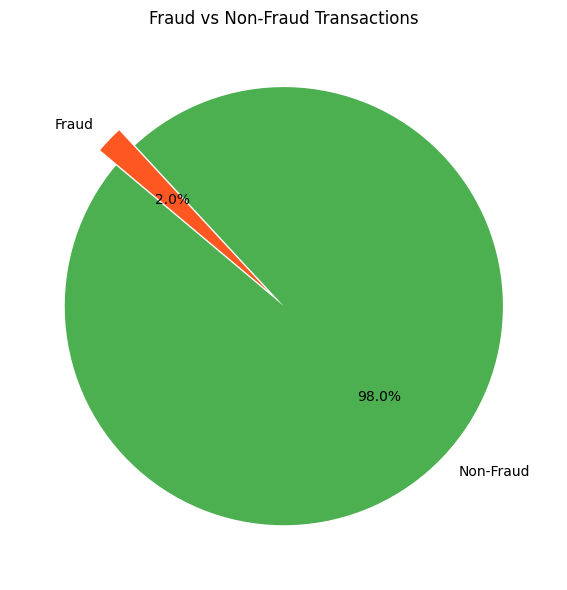

In [ ]:
# We now check how many transactions were involved for Fraud vs Non-fraud Transactions
fraud_counts = data['fraud_flag'].value_counts()


labels = ['Non-Fraud', 'Fraud'] if 0 in fraud_counts.index else ['Fraud', 'Non-Fraud']

plt.figure(figsize=(6, 6))
plt.pie(fraud_counts.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#4CAF50', '#FF5722'],
        explode=(0, 0.1) if 1 in fraud_counts.index else (0.1, 0))

plt.title('Fraud vs Non-Fraud Transactions')
plt.tight_layout()
plt.show()

* We see there are only 0.2% Fraudelent transactions compared to the 99.8% Non-Fraudelent Transactions.

* This imbalance can cause the model to perform poorly in detecting fraud, as it tends to predict the majority class.

* SMOTE can be applied to generate synthetic samples of the minority (fraudulent) class to balance the dataset.

* Applying SMOTE helps the model learn better decision boundaries, improving fraud detection performance in terms of recall and F1-score.

**Transaction Distribution**

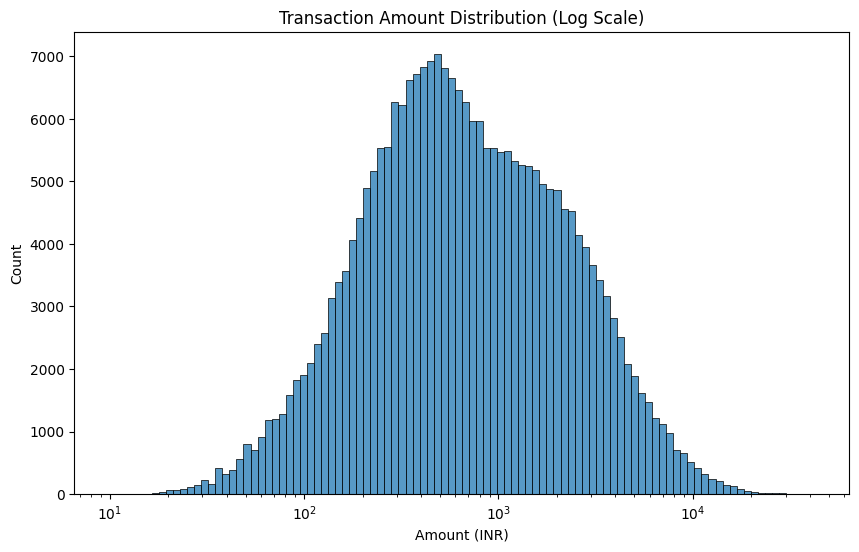

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data['amount (INR)'], bins=100, log_scale=True)
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount (INR)')
plt.ylabel('Count')
plt.show()

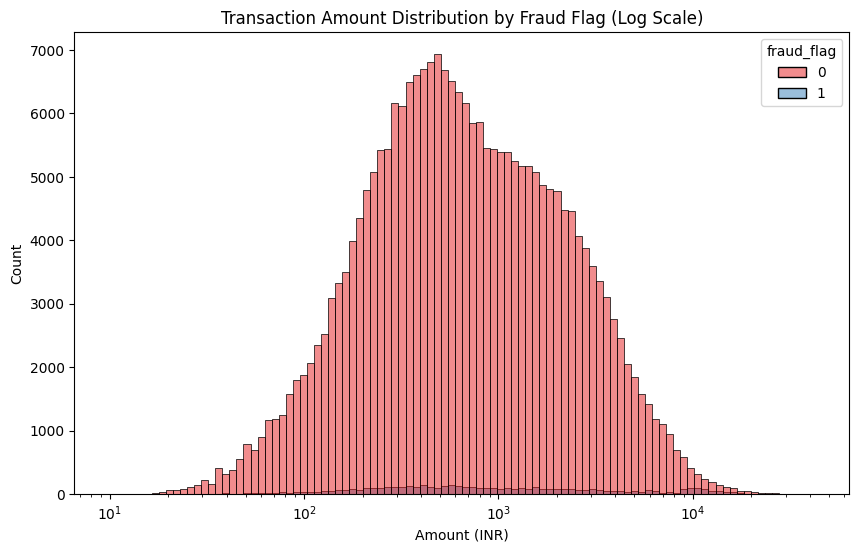

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='amount (INR)', hue='fraud_flag', bins=100, log_scale=True, palette='Set1')
plt.title('Transaction Amount Distribution by Fraud Flag (Log Scale)')
plt.xlabel('Amount (INR)')
plt.ylabel('Count')
plt.show()


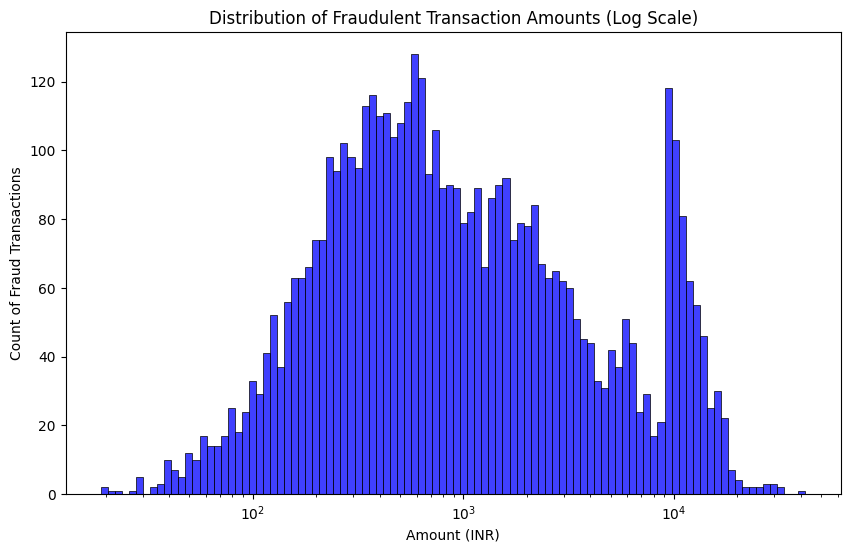

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=data[data['fraud_flag'] == 1], x='amount (INR)', bins=100, log_scale=True, color='blue')
plt.title('Distribution of Fraudulent Transaction Amounts (Log Scale)')
plt.xlabel('Amount (INR)')
plt.ylabel('Count of Fraud Transactions')
plt.show()


**Transaction Type Distributed**

/tmp/ipykernel_3286/3230912546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='transaction type', data=data, palette='Set2')


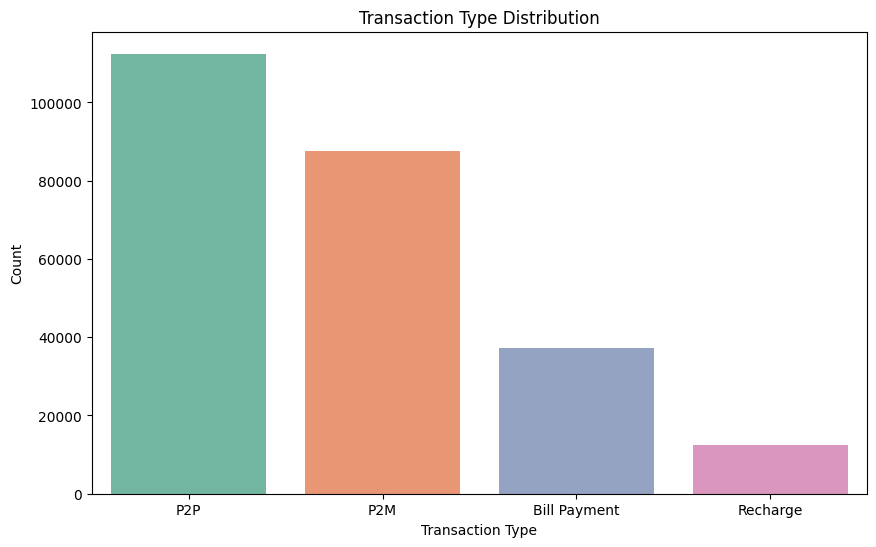

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='transaction type', data=data, palette='Set2')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_3286/1541271765.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='transaction type', data=data[data['fraud_flag'] == 1], palette='Set1')


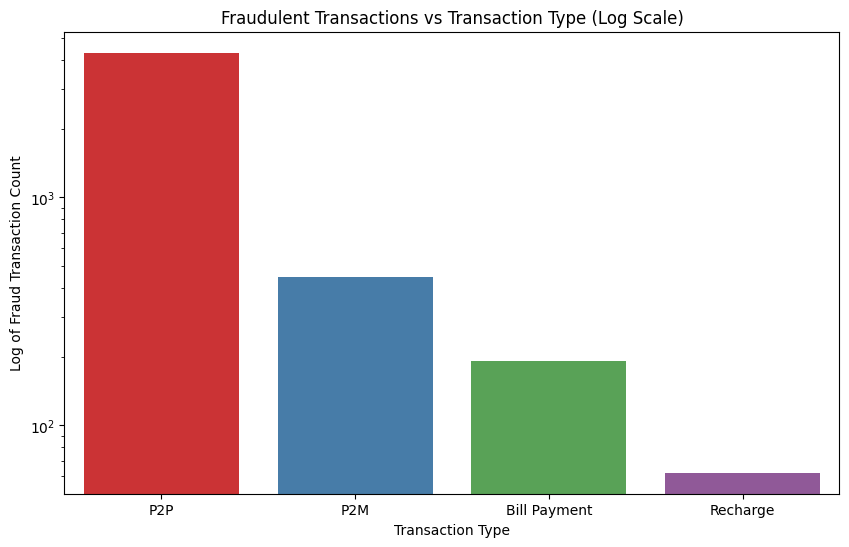

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='transaction type', data=data[data['fraud_flag'] == 1], palette='Set1')
plt.yscale('log')
plt.title('Fraudulent Transactions vs Transaction Type (Log Scale)')
plt.xlabel('Transaction Type')
plt.ylabel('Log of Fraud Transaction Count')
plt.show()

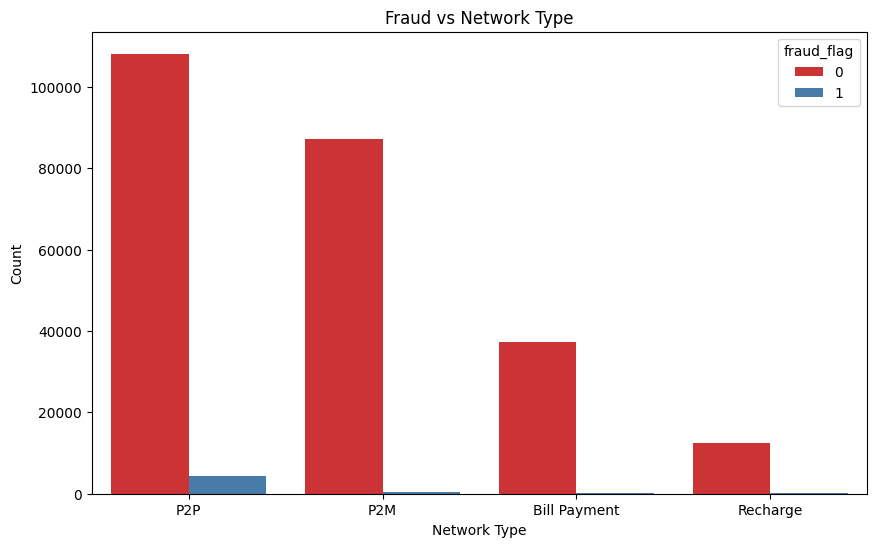

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='transaction type', hue='fraud_flag', data=data, palette='Set1')
plt.title('Fraud vs Network Type')
plt.xlabel('Network Type')
plt.ylabel('Count')
plt.show()

The log scale allows us to clearly see the presence of fraudulent transactions (fraud_flag = 1) in both P2P and P2M types.

Fraud occurs more frequently in P2P transactions compared to P2M, which is less obvious without log scaling.

**Hour of Day Distribution**

/tmp/ipykernel_3286/3879589651.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour_of_day', data=data, palette='Set2')


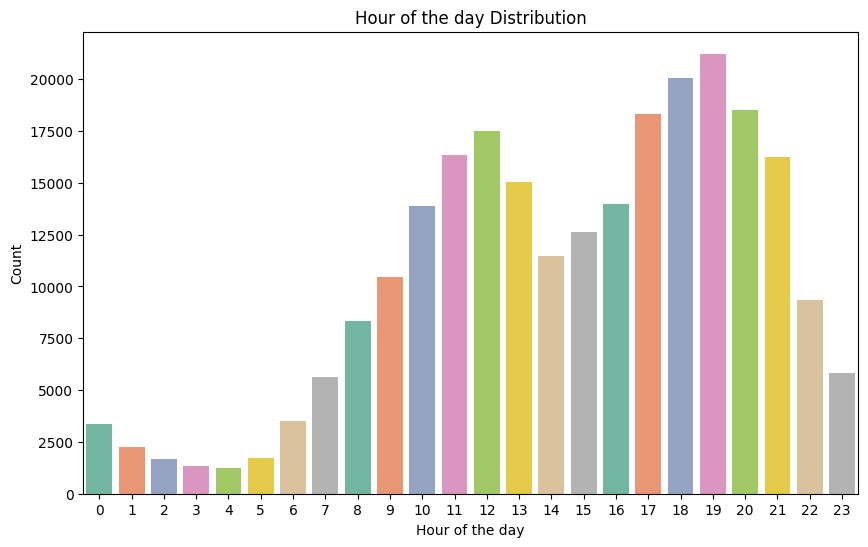

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='hour_of_day', data=data, palette='Set2')
plt.title('Hour of the day Distribution')
plt.xlabel('Hour of the day')
plt.ylabel('Count')
plt.show()

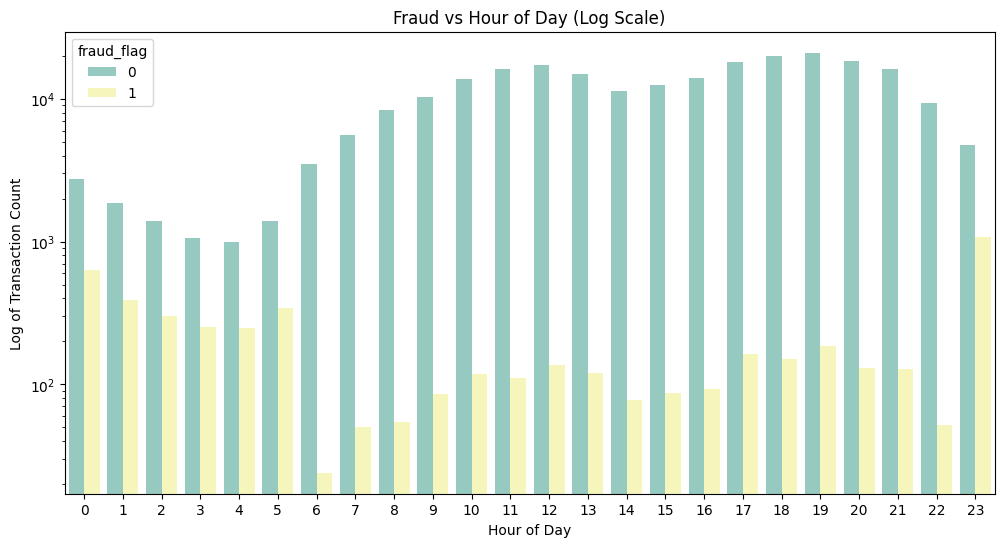

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='hour_of_day', hue='fraud_flag', data=data, palette='Set3')
plt.yscale('log')
plt.title('Fraud vs Hour of Day (Log Scale)')
plt.xlabel('Hour of Day')
plt.ylabel('Log of Transaction Count')
plt.show()

* Fraudulent transactions occur throughout the day.

* Slight concentration of fraud during late night and early morning hours (odd hours).


**Fraud vs Network Type**

/tmp/ipykernel_3286/997744253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='network_type', data=data, palette='Set2')


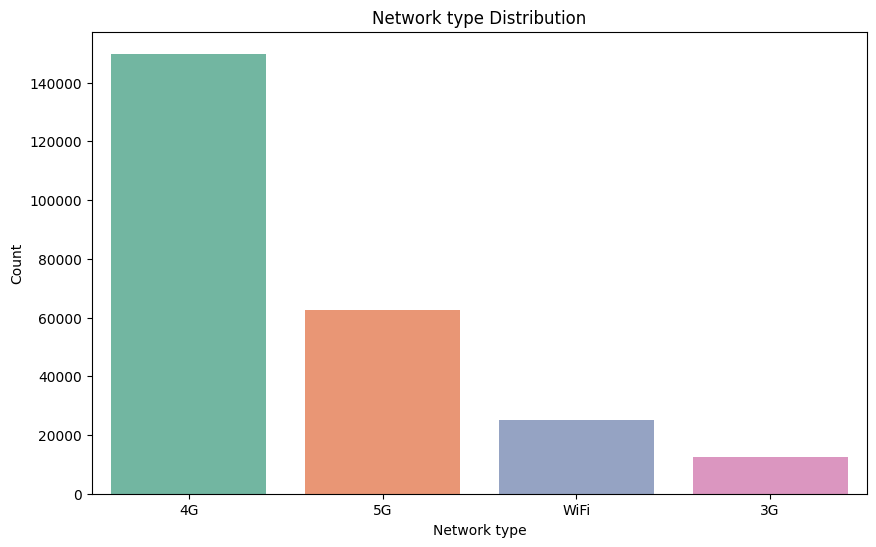

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='network_type', data=data, palette='Set2')
plt.title('Network type Distribution')
plt.xlabel('Network type')
plt.ylabel('Count')
plt.show()

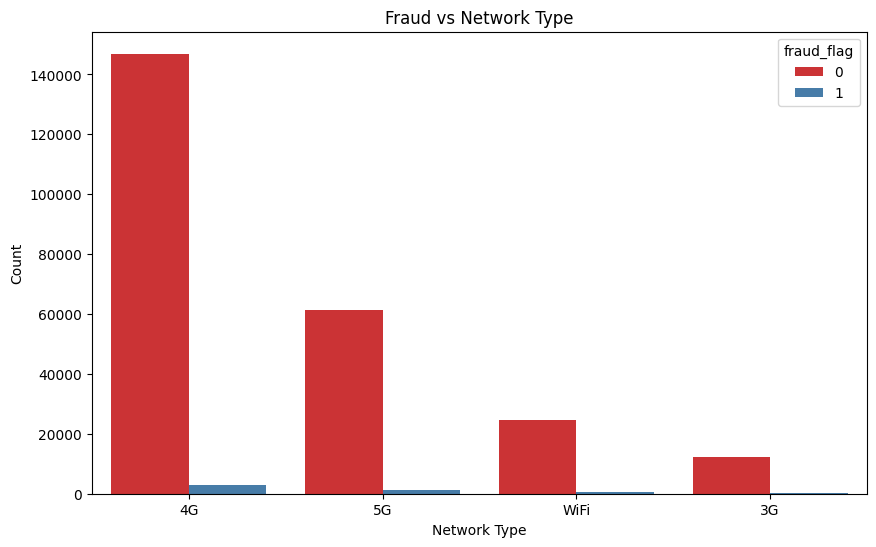

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='network_type', hue='fraud_flag', data=data, palette='Set1')
plt.title('Fraud vs Network Type')
plt.xlabel('Network Type')
plt.ylabel('Count')
plt.show()


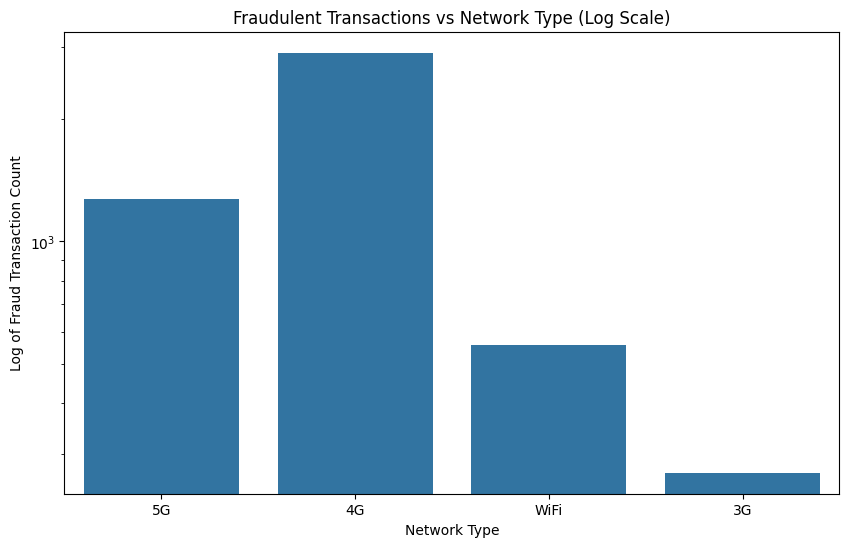

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='network_type', data=data[data['fraud_flag'] == 1])
plt.yscale('log')
plt.title('Fraudulent Transactions vs Network Type (Log Scale)')
plt.xlabel('Network Type')
plt.ylabel('Log of Fraud Transaction Count')
plt.show()

* Fraudulent transactions occur over 4G, 5G, and WiFi.

* No strong preference is visible in network type for fraud.

**Fraud vs Merchant Category**

/tmp/ipykernel_3286/1182888285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='merchant_category', data=data, palette='Set2')


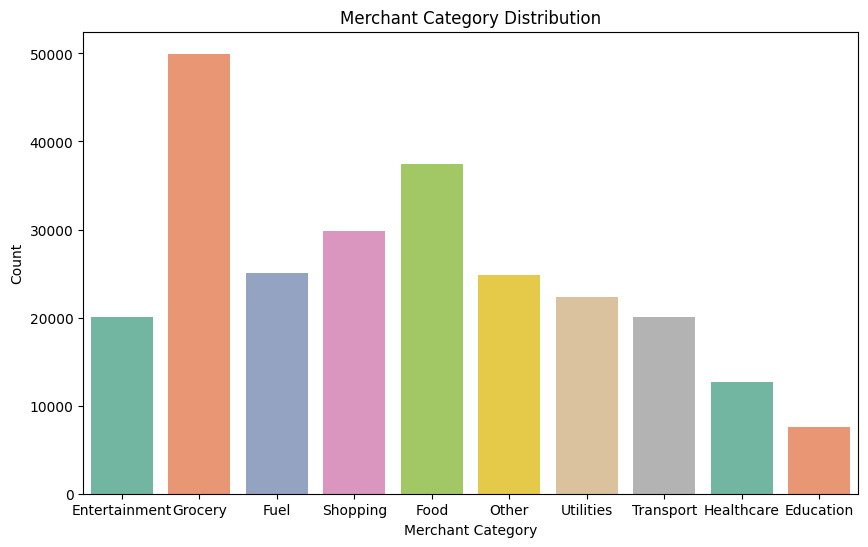

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='merchant_category', data=data, palette='Set2')
plt.title('Merchant Category Distribution')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.show()

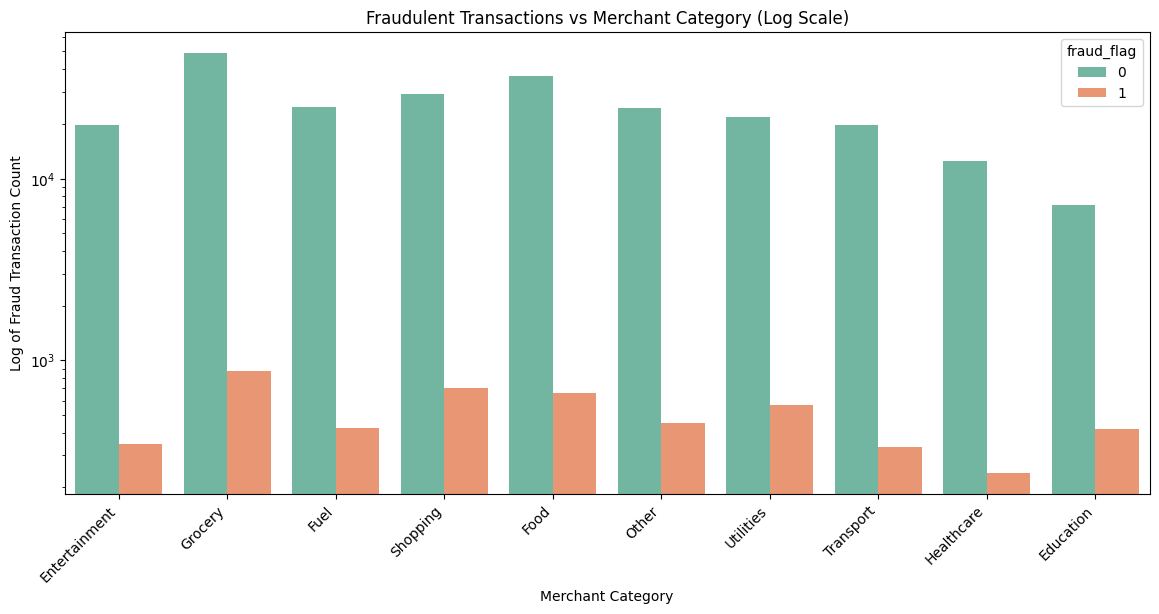

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(x='merchant_category', hue = 'fraud_flag',data=data, palette='Set2', )
plt.yscale('log')
plt.title('Fraudulent Transactions vs Merchant Category (Log Scale)')
plt.xlabel('Merchant Category')
plt.ylabel('Log of Fraud Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.show()


/tmp/ipykernel_3286/800167732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='merchant_category', data=data[data['fraud_flag'] == 1], palette='Set2', order=data[data['fraud_flag'] == 1]['merchant_category'].value_counts().index)


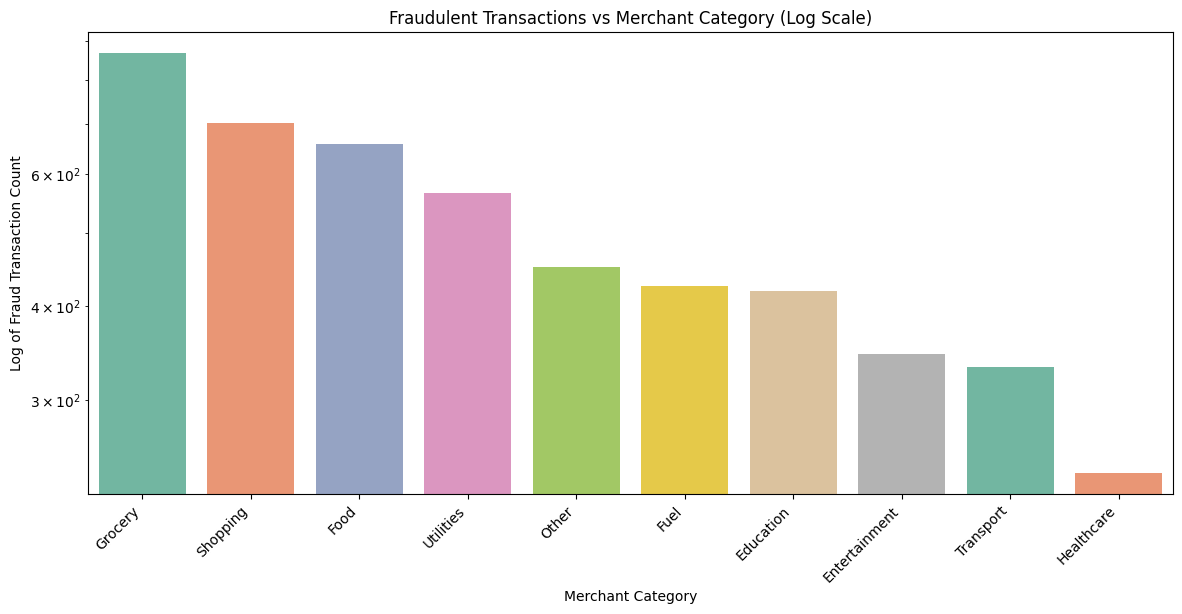

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(x='merchant_category', data=data[data['fraud_flag'] == 1], palette='Set2', order=data[data['fraud_flag'] == 1]['merchant_category'].value_counts().index)
plt.yscale('log')
plt.title('Fraudulent Transactions vs Merchant Category (Log Scale)')
plt.xlabel('Merchant Category')
plt.ylabel('Log of Fraud Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.show()


* Fraudulent transactions are spread across many merchant categories such as Entertainment, Grocery, Shopping, Fuel, etc.

* Certain categories like Entertainment and Shopping show a slightly higher proportion of fraud.

**Sender age Distribution**

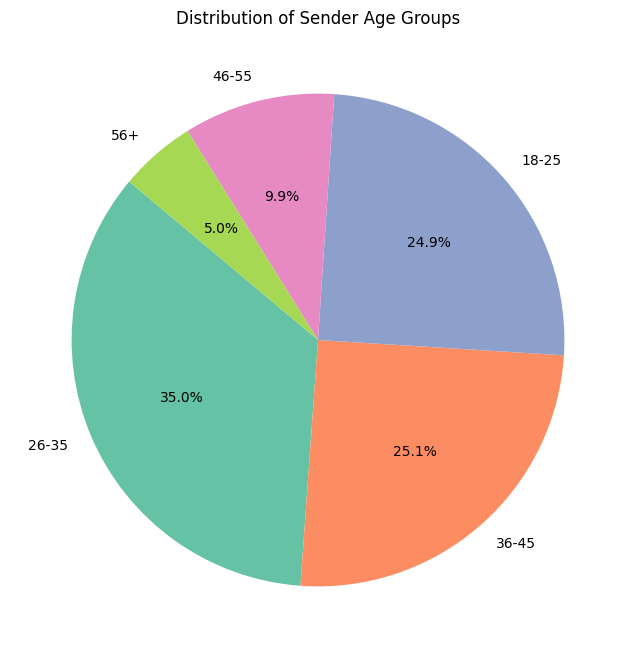

In [ ]:
age_counts = data['sender_age_group'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(age_counts.values,
        labels=age_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2'))

plt.title('Distribution of Sender Age Groups')
plt.show()


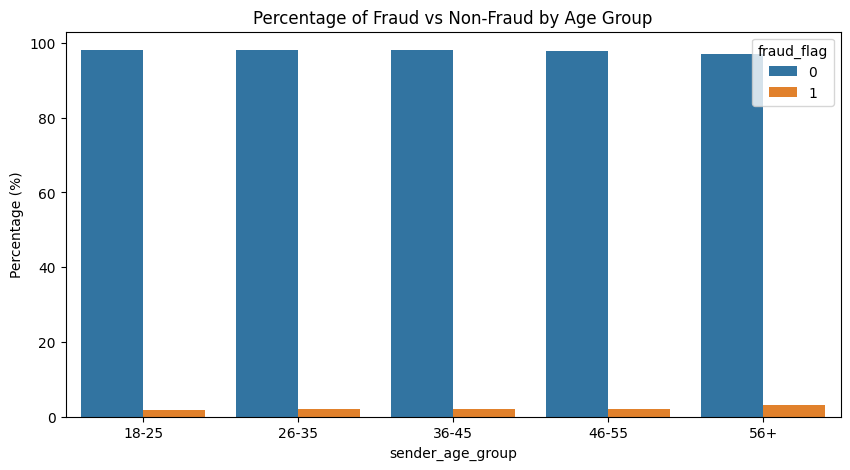

In [ ]:
age_fraud = data.groupby(["sender_age_group","fraud_flag"]).size().reset_index(name="count")
age_fraud["percent"] = age_fraud.groupby("sender_age_group")["count"].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=(10,5))
sns.barplot(data=age_fraud, x="sender_age_group", y="percent", hue="fraud_flag")
plt.title("Percentage of Fraud vs Non-Fraud by Age Group")
plt.ylabel("Percentage (%)")
plt.show()


Fraudulent transactions tend to involve higher amounts and a wider distribution compared to non-fraudulent ones, especially in middle age groups (36–45, 46–55).
This pattern suggests fraudsters often attempt to conduct high-value transactions to exploit vulnerabilities.
The log scale reveals the wide disparity and outliers more clearly, emphasizing the importance of monitoring large transactions for fraud detection.

---



**Summary of Univariate Analysis**
* Hour of Day: Most transactions occur during working hours (9 AM – 6 PM). Very few happen during late night (12 AM – 5 AM).

* Transaction Type: Majority are Person-to-Merchant (P2M), while  Person-to-Person (P2P) is less frequent but still significant.

* Merchant Category: Shopping and Entertainment dominate transaction volume, followed by Bill Payments.

* Device Type: Mobile devices (Android & iOS) dominate usage, while desktop/web transactions are fewer.

* Network Type: Mobile data (4G/5G) is most common, Wi-Fi is secondary, and 2G/3G is negligible.

* Fraud Flag: Only a small proportion (~1–3%) of total transactions are fraudulent, meaning fraud is rare compared to genuine transactions.

---

**Summary of Bi-variate Analysis**
* Fraud vs Hour of Day: Fraud is spread across the day but shows a slightly higher concentration in off-peak hours (late night/early morning) when fewer genuine transactions occur.

* Fraud vs Transaction Type: Fraud is relatively higher in P2P transactions compared to P2M, likely due to ease of money movement between individuals.

* Fraud vs Merchant Category: Fraudulent activity is seen more in Entertainment and Shopping categories, possibly due to digital goods/services being easier to exploit.

* Fraud vs Device Type: Android devices show more fraudulent activity than iOS or desktops, indicating possible weaker security in certain user segments.

* Fraud vs Network Type: Fraud is fairly distributed, but a slight tilt towards Mobile Data (4G/5G) suggests fraudsters prefer mobile transactions over Wi-Fi.

----

**Overall Conclusion:**

* Normal transactions cluster in working hours, P2M, shopping, Android, and 4G/5G networks.

* Fraudulent transactions, while rare, lean towards P2P, night-time, Android, and certain merchant categories like Entertainment.

**FEATURE ENGINEERING**

1. Handling Null Values

In [ ]:
data = data.dropna()

Columns with 1 missing: receiver_age_group, sender_state, sender_bank, receiver_bank, device_type, network_type, fraud_flag, hour_of_day, day_of_week, is_weekend. So, we can drop the single missing row.

2. Drop Irrelevant Columns

In [ ]:
data = data.drop(["transaction id", "timestamp"], axis=1)

3. Encoding Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [ ]:
df = data.copy()

In [ ]:
ohe_tt = OneHotEncoder(sparse_output=False)
transaction_encoded = ohe_tt.fit_transform(df[['transaction type']])

transaction_encoded_df = pd.DataFrame(transaction_encoded,
                                      columns=ohe_tt.get_feature_names_out(['transaction type']))

df = pd.concat([df.drop('transaction type', axis=1), transaction_encoded_df], axis=1)
df.head(15)

,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_notes,date,transaction type_Bill Payment,transaction type_P2M,transaction type_P2P,transaction type_Recharge
0,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,Zomato food order.,2024-10-08 15:17:00,0.0,0.0,1.0,0.0
1,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,Payment to milkman.,2024-04-11 06:56:00,0.0,1.0,0.0,0.0
2,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,Petrol for bike.,2024-04-02 13:27:00,0.0,0.0,1.0,0.0
3,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,Office coffee split.,2024-01-07 10:09:00,0.0,0.0,1.0,0.0
4,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,Zomato food order.,2024-01-23 19:04:00,0.0,0.0,1.0,0.0
5,Food,91,SUCCESS,36-45,18-25,Karnataka,IndusInd,Yes Bank,Android,3G,0,22,Monday,0,Weekend movie tickets.,2024-10-07 22:32:00,0.0,0.0,1.0,0.0
6,Other,314,SUCCESS,36-45,18-25,Telangana,HDFC,IndusInd,Android,4G,0,10,Thursday,0,Payment for shopping at Mall.,2024-02-08 10:25:00,0.0,0.0,1.0,0.0
7,Utilities,264,SUCCESS,46-55,36-45,Maharashtra,Yes Bank,SBI,Android,5G,0,18,Sunday,1,Birthday gift for Rohan.,2024-10-27 18:47:00,0.0,0.0,1.0,0.0
8,Other,887,SUCCESS,46-55,36-45,Maharashtra,Kotak,HDFC,Android,4G,0,9,Thursday,0,Maid salary.,2024-11-21 09:39:00,0.0,0.0,1.0,0.0
9,Grocery,3260,SUCCESS,46-55,18-25,Delhi,SBI,HDFC,Android,4G,0,15,Monday,0,Zomato food order.,2024-11-11 15:58:00,0.0,1.0,0.0,0.0


In [ ]:
ohe = OneHotEncoder(sparse_output=False)
merchant_encoded = ohe.fit_transform(df[['merchant_category']])
merchant_encoded_df = pd.DataFrame(merchant_encoded,
                                   columns=ohe.get_feature_names_out(['merchant_category']))
df = pd.concat([df.drop('merchant_category', axis=1), merchant_encoded_df], axis=1)


In [ ]:
age_map = {
    '18-25': 0,
    '26-35': 1,
    '36-45': 2,
    '46-55': 3,
    '56-65': 4,
    '56+': 4,
    '65+': 5
}
for col in ['sender_age_group', 'receiver_age_group']:
    df[col] = df[col].astype(str) \
                     .str.strip() \
                     .str.replace('\t','', regex=True) \
                     .str.replace('\n','', regex=True) \
                     .str.replace('–','-', regex=False) \
                     .str.replace(' ', '', regex=True)  # remove internal spaces if any

# Replace unknowns with a default value before mapping
default_age = '18-25'
df['sender_age_group'] = df['sender_age_group'].apply(lambda x: x if x in age_map else default_age)
df['receiver_age_group'] = df['receiver_age_group'].apply(lambda x: x if x in age_map else default_age)

# Now map safely
df['sender_age_group'] = df['sender_age_group'].map(age_map)
df['receiver_age_group'] = df['receiver_age_group'].map(age_map)

In [ ]:
rows_with_nulls = df[df.isnull().any(axis=1)]
print(rows_with_nulls)

Empty DataFrame
Columns: [amount (INR), transaction_status, sender_age_group, receiver_age_group, sender_state, sender_bank, receiver_bank, device_type, network_type, fraud_flag, hour_of_day, day_of_week, is_weekend, transaction_notes, date, transaction type_Bill Payment, transaction type_P2M, transaction type_P2P, transaction type_Recharge, merchant_category_Education, merchant_category_Entertainment, merchant_category_Food, merchant_category_Fuel, merchant_category_Grocery, merchant_category_Healthcare, merchant_category_Other, merchant_category_Shopping, merchant_category_Transport, merchant_category_Utilities]
Index: []

[0 rows x 29 columns]


In [ ]:
df.isnull().sum()

,0
amount (INR),0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0
receiver_bank,0
device_type,0
network_type,0
fraud_flag,0


In [ ]:
for col in ['sender_state', 'sender_bank', 'receiver_bank']:
    freq_encoding = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq_encoding)

In [ ]:
ohe2 = OneHotEncoder(sparse_output=False)
device_net_encoded = ohe2.fit_transform(df[['device_type','network_type']])
device_net_encoded_df = pd.DataFrame(device_net_encoded,
                                     columns=ohe2.get_feature_names_out(['device_type','network_type']))
df = pd.concat([df.drop(['device_type','network_type'], axis=1), device_net_encoded_df], axis=1)

In [ ]:
day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2,
           'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
df['day_of_week_num'] = df['day_of_week'].map(day_map)
df = df.drop('day_of_week', axis=1)

In [ ]:
status_map = {'FAILED': 0, 'PENDING': 1, 'SUCCESS': 2}
df['transaction_status'] = df['transaction_status'].map(status_map)

In [ ]:
df.head()

,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,fraud_flag,hour_of_day,is_weekend,...,merchant_category_Transport,merchant_category_Utilities,device_type_Android,device_type_Web,device_type_iOS,network_type_3G,network_type_4G,network_type_5G,network_type_WiFi,day_of_week_num
0,868,2,1,0,0.099480,0.100168,0.249512,0,15,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,1011,2,1,1,0.120500,0.119076,0.099968,0,6,0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3
2,477,2,1,2,0.119024,0.099440,0.099208,0,13,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,2784,2,1,1,0.099480,0.119076,0.099208,0,10,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6
4,990,2,1,0,0.099480,0.100168,0.100036,0,19,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1


1. `transaction type` (P2P, P2M, Recharge, Bill Payment) → **One-hot Encoding**
* Multi-class **nominal** (no natural order).
* One-hot prevents giving a false ranking

---

2. `merchant_category` (Grocery, Shopping, Fuel, Entertainment, etc.) → **One-Hot Encoding**

  * Multi-class **nominal** (no natural order).
  * One-hot prevents giving a false ranking (e.g., Grocery < Shopping).
  * Expands into separate columns like `merchant_Grocery`, `merchant_Shopping`.

---

3. `sender_age_group` & `receiver_age_group` (18–25, 26–35, 36–45, etc.) → **Ordinal Encoding (Custom Mapping)**


  * **Ordered categories** (younger → older).
  * Encoding them as `0, 1, 2, …` preserves the **age progression**.
  * Example: 18–25 → 0, 26–35 → 1, etc.

---

4. `sender_state`, `sender_bank`, `receiver_bank` → **Frequency Encoding**

  * **High cardinality** (many unique categories).
  * One-hot encoding would create hundreds of columns (sparse, memory-heavy).
  * Frequency encoding replaces each category with its relative frequency in dataset.
  * Example: If SBI = 30% of rows → encoded as 0.30.

---
5. `device_type`, `network_type` (Mobile/Tablet, 3G/4G/5G/WiFi) → **One-Hot Encoding**
  * Few unique categories (low cardinality).
  * One-hot encoding keeps interpretability, helps model detect fraud patterns per device/network.

---
6. `transaction_status` (FAILED, PENDING, SUCCESS) → **Ordinal Encoding**

  * Categories have **natural order** (Failed < Pending < Success).
  * Mapping: FAILED → 0, PENDING → 1, SUCCESS → 2.
  * Preserves the business meaning that “Success” is higher than “Pending” or “Failed”.
---

